The notebook is divided in these parts:
## 1.   *Importing Libraries*
## 2.   *Importing Dataset*
## 3.   *Preprocessing*
## 4.   *Feature Engineering*
## 5.   *Model Training*
## 6.   *Evaluation and Prediction*
## 7.   *Deployment*
---

# 📔 Project Notebook Structure
```bibtex
1. Tasks are distributed across teams and organized by notebook titles
   Each notebook documents:
    - Code implementation for task completion
    - Relevant comments and annotations

2. Agile Project Methodology:
    Weekly iterations training 1-2 models

    Project completion criteria:
        Best performing model achieves target evaluation metrics

3. The Pipeline of notebook:
   a. Doing EDA on dataset and finding information about that
   
   b. Applying preprocessing on dataset by information:
      i.   Class balancing
      ii.  Data augmentation
      iii. Normalization
      iv.  De-noising

   c. Feature extraction:
      i. Using some trained model
      ii. Extracting using Deep Learning (MFCC, MEL spectograms)

   d. Model training:
      i. Using trained model and fine tune that
      ii. Implement from scratch with torch, keras

   e. Evaluation with accuracy, precision, recall, f1-score (Confusion Matrix)
```

💡 Tips:
``` python
  1. For unfinished section use this: #TODO
  2. The structure of task like this:
      # [TASK NAME] (Assignee: @username)
      # Sprint Goal: [e.g., "Improve Wav2Vec2 accuracy by 5%"]
      # Deadline: DD/MM  
```


# 1. *Libraries*



**Installing**



In [ ]:
!pip install numpy==2.0.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 48.4 MB/s eta 0:00:00


In [ ]:
!pip install noisereduce openai-whisper datasets evaluate jiwer -q -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.7 MB/s eta 0:00:00


**Importing**

In [ ]:
# For Data Processing
import numpy as np
import pandas as pd
import os
import shutil
import random
from sklearn.utils import shuffle
from tqdm import tqdm
from pathlib import Path

#  For Plotting
import matplotlib.pyplot as plt
import seaborn as sns


# For Speech Processing
import librosa
import scipy.signal as signal
import IPython.display as ipd
import soundfile as sf
import noisereduce as nr

# For DL, Classifier,... Model (Sklearn, pytorch, keras, Tensorflow,...)
import tensorflow_hub as hub

# TODO: need to be fixed by version
import whisper
# import openl3
import torch
import torchaudio
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import Wav2Vec2Processor, Wav2Vec2Model, Wav2Vec2ForCTC
from sklearn.model_selection import train_test_split
from evaluate import load
from evaluate import visualization


# If you need other libraries to be imported write it here
import kagglehub
from abc import ABC, abstractmethod
from dataclasses import dataclass


# *2. Dataset - EDA*

Importing Dataset - (Assignee: Sepehr)\
Sprint Goal: [Importing Dataset from kaggle and making a folder in colab]\
Deadline: 02/May

In [ ]:
# Importing Dataset From Kaggle
path = kagglehub.dataset_download("sepehrsimkhah/speech-dataset-pazhvak")

print("Path to dataset files:", path)

100%|██████████| 3.77G/3.77G [00:38<00:00, 104MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sepehrsimkhah/speech-dataset-pazhvak/versions/1


In [ ]:
# Validating Dataset Path
list_of_dataset = os.listdir(path)
list_of_dataset

['2001-2400',
 '401-800',
 '801-1200',
 'P1993818924117826_1247741184149835.xlsx',
 '2401-2800',
 '1-400',
 '1601-2000',
 '1201-1600',
 '3201-3600',
 '2801-3200',
 '3601-4018']

In [ ]:
word_table = os.path.join(path, 'P1993818924117826_1247741184149835.xlsx')
df = pd.read_excel(word_table)
df.sample(5)

,Folder Number,Persian Word
3399,3400,ران
2884,2885,شرط
1184,1185,می گذرید
1428,1429,فهمیدید
1791,1792,بخندند


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Folder Number  4018 non-null   int64 
 1   Persian Word   4017 non-null   object
dtypes: int64(1), object(1)
memory usage: 62.9+ KB


In [ ]:
df.isna()

,Folder Number,Persian Word
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
4013,False,False
4014,False,False
4015,False,False
4016,False,False


## TODO: Fixing the voice problem (assignee: Sepehr)

In [ ]:
# by doing this we found out that we have a nan value
df_false = df[df.isna().any(axis=1)]
df_false

,Folder Number,Persian Word
662,663,NaN


i listend the voices of folder 663th and i found out that the 663 is "کارفرما"

In [ ]:
row = df[df["Persian Word"] == "کارفرما"]
row

,Folder Number,Persian Word
3778,3779,کارفرما


this word has two folders, I Don't know why but:\
a folder is "کارفرما" with men voices (3779)\
the other one is "کارفرما" with women voices (663)

In [ ]:
# it's 10 folders
list_of_folders = list_of_dataset.copy()
list_of_folders.remove('P1993818924117826_1247741184149835.xlsx')
list_of_folders

['2001-2400',
 '401-800',
 '801-1200',
 '2401-2800',
 '1-400',
 '1601-2000',
 '1201-1600',
 '3201-3600',
 '2801-3200',
 '3601-4018']

این شخص کلمه "شستن" رو خیلی باحال گفته به همین خاطر رانش نکنید

In [ ]:
# finding the audio of word by number folder

def find_word_range(folder_number:int, folders:list):
  for word_range in folders:
    start_word_range, stop_word_range = word_range.split("-")
    if int(start_word_range) <= folder_number <= int(stop_word_range):
      return start_word_range, stop_word_range, word_range

random_number_folder = random.randint(0, 4018)
word = (df[df["Folder Number"] == random_number_folder])["Persian Word"].values[0]
_, _, word_range = find_word_range(random_number_folder, list_of_folders)
path_example = os.path.join(f"{path}/{word_range}/{random_number_folder}/")
list_audio_example = os.listdir(path_example)
audio_file = path_example + list_audio_example[random.randint(0, len(list_audio_example)-1)]

print(f"Word: {word}")
print("Loading:", audio_file)
assert os.path.exists(audio_file), f"File {audio_file} not found!"

y, sr = librosa.load(audio_file, sr=None)
print(sr)
ipd.Audio(y, rate=sr)



Word: 204    شستن
Name: Persian Word, dtype: object
Loading: /kaggle/input/speech-dataset-pazhvak/1-400/205/FA_16000_0013.wav
16000


In [ ]:
# Some Examples

def play_audio_samples(path:str, word_table:pd.DataFrame, folders:list, num_samples:int=2):
    for _ in range(num_samples):
        random_number_folder = random.randint(0, len(word_table) - 1)

        word_row = word_table[word_table["Folder Number"] == random_number_folder]
        if word_row.empty:
            continue

        word = word_row["Persian Word"].values[0]
        start_range, end_range, word_range = find_word_range(random_number_folder, folders)

        folder_path = os.path.join(path, word_range, str(random_number_folder))
        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue

        audio_files = os.listdir(folder_path)
        if not audio_files:
            print(f"No audio files in: {folder_path}")
            continue

        audio_file = os.path.join(folder_path, random.choice(audio_files))

        print(f"\nWord: {word} (Folder: {random_number_folder})")
        print(f"Audio file: {audio_file}")

        try:
            y, sr = librosa.load(audio_file, sr=None)
            display(ipd.Audio(y, rate=sr))
        except Exception as e:
            print(f"Error loading audio: {e}")

In [ ]:
play_audio_samples(path=path,word_table=df,folders=list_of_folders,num_samples=3)


Word: شنید  (Folder: 120)
Audio file: /kaggle/input/speech-dataset-pazhvak/1-400/120/FA_16000_0008.wav



Word: سوراخ (Folder: 591)
Audio file: /kaggle/input/speech-dataset-pazhvak/401-800/591/FA_16000_0021.wav



Word: زمین شناس (Folder: 3915)
Audio file: /kaggle/input/speech-dataset-pazhvak/3601-4018/3915/FA_16000_0015.wav


EDA On Dataset - (Assignee: Sepehr)\
Sprint Goal: [Using some functions to analyzing voices and getting some informations]\
Deadline: 02/May

In [ ]:
class IAudioAnalyzer(ABC):
    @abstractmethod
    def analyze(self, signal: np.ndarray, sample_rate: int) -> dict:
        pass

    @abstractmethod
    def plot(self, signal: np.ndarray, sample_rate: int):
        pass

#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<Audio Analysis>>>>>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

@dataclass
class AudioSample:
    signal: np.ndarray
    sample_rate: int
    metadata: dict = None

class AudioAnalyzer:
    def __init__(self, audio_sample: AudioSample):
        self.audio = audio_sample

    def raw_waveform_plot(self):
        plt.figure(figsize=(12, 4))
        librosa.display.waveshow(y=self.audio.signal, sr=self.audio.sample_rate)
        plt.title("Raw Waveform")
        plt.show()

    def fft_spectrum_plot(self):
        fft = np.fft.fft(self.audio.signal)
        freq = np.fft.fftfreq(len(self.audio.signal), 1/self.audio.sample_rate)
        plt.figure(figsize=(12, 4))
        plt.plot(freq[:len(freq)//2], np.abs(fft)[:len(freq)//2])
        plt.title("FFT Spectrum")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.show()

    def stft_spectrogram_plot(self, scale: str = "log"):
        D = librosa.stft(self.audio.signal, n_fft=2048, hop_length=512)
        s_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(s_db, sr=self.audio.sample_rate,
                                hop_length=512, x_axis='time', y_axis=scale)
        plt.colorbar(format='%+2.0f dB')
        plt.title("STFT Spectrogram")
        plt.show()

    def mel_spectrogram_plot(self, n_mels: int = 80):
        S = librosa.feature.melspectrogram(y=self.audio.signal, sr=self.audio.sample_rate, n_mels=n_mels)
        S_db = librosa.power_to_db(S, ref=np.max)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(S_db, sr=self.audio.sample_rate, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title("Mel Spectrogram")
        plt.show()
        return S_db

    def mfcc_plot(self, n_mfcc: int = 13):
        mfccs = librosa.feature.mfcc(y=self.audio.signal, sr=self.audio.sample_rate, n_mfcc=n_mfcc)
        plt.figure(figsize=(12, 4))
        librosa.display.specshow(mfccs, sr=self.audio.sample_rate, x_axis='time')
        plt.colorbar()
        plt.title("MFCC Features")
        plt.show()


In [ ]:
#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<<Word Analysis>>>>>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

class WordAnalyzer:
    def __init__(self, dataset: 'PazhvakDataset'):
        self.dataset = dataset

    def word_count(self) -> pd.DataFrame:
        word_stats = []

        for word, group in self.dataset.metadata.groupby('Persian Word'):
            voice_count = 0
            folder_count = len(group)

            for _, row in group.iterrows():
                folder_num = row['Folder Number']
                word_range = self.dataset._find_word_range(folder_num)
                folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

                if os.path.exists(folder_path):
                    voice_count += len([f for f in os.listdir(folder_path)
                                     if f.endswith(('.wav', '.mp3', '.flac'))])

            word_stats.append({
                'Persian Word': word,
                'Voice Count': voice_count,
                'Folder Count': folder_count
            })

        return pd.DataFrame(word_stats)

    def most_common_words(self, top_n: int = 10) -> pd.DataFrame:
        word_stats = self.word_count()
        return word_stats.sort_values('Voice Count', ascending=False).head(top_n)

    def least_common_words(self, top_n: int = 10) -> pd.DataFrame:
        word_stats = self.word_count()
        return word_stats.sort_values('Voice Count').head(top_n)

    def plot_voice_distribution(self):
        word_stats = self.word_count()
        voice_counts = word_stats['Voice Count'].value_counts().sort_index()

        plt.figure(figsize=(12, 6))
        voice_counts.plot(kind='bar')
        plt.title("Distribution of Voice Counts per Word")
        plt.xlabel("Number of Voices")
        plt.ylabel("Number of Words")
        plt.grid(True)
        plt.show()

In [ ]:
#-------------------------------------------------------------
#<<<<<<<<<<<<<<<<<<<Dataset Statistics>>>>>>>>>>>>>>>>>>>>>>>>
#-------------------------------------------------------------

class DatasetStatistics:
    def __init__(self, dataset: 'PazhvakDataset'):
        self.dataset = dataset

    def analyze_durations(self) -> dict:
        durations = []
        total_files = 0

        for _, row in tqdm(self.dataset.metadata.iterrows(), total=len(self.dataset.metadata), desc="Analyzing durations"):
            folder_num = row['Folder Number']
            word_range = self.dataset._find_word_range(folder_num)
            folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

            if os.path.exists(folder_path):
                audio_files = [f for f in os.listdir(folder_path)
                             if f.endswith(('.wav', '.mp3', '.flac'))]
                total_files += len(audio_files)

                for file in audio_files:
                    try:
                        y, sr = librosa.load(os.path.join(folder_path, file), sr=None)
                        durations.append(len(y)/sr)
                    except:
                        continue

        if not durations:
            return {}

        avg_dur = sum(durations)/len(durations)
        max_dur = max(durations)
        min_dur = min(durations)

        above_avg = sum(1 for d in durations if d > avg_dur)
        below_avg = len(durations) - above_avg

        return {
            'avg': avg_dur,
            'max': max_dur,
            'min': min_dur,
            'above_avg': above_avg,
            'below_avg': below_avg,
            'total_files': total_files
        }

    def plot_duration_distribution(self, sample_size: int = 500):
        durations = []
        sampled_metadata = self.dataset.metadata.sample(min(sample_size, len(self.dataset.metadata)))

        for _, row in tqdm(sampled_metadata.iterrows(), total=len(sampled_metadata), desc="Sampling durations"):
            folder_num = row['Folder Number']
            word_range = self.dataset._find_word_range(folder_num)
            folder_path = os.path.join(self.dataset.dataset_path, word_range, str(folder_num))

            if os.path.exists(folder_path):
                audio_files = [f for f in os.listdir(folder_path)
                             if f.endswith(('.wav', '.mp3', '.flac'))]
                for file in audio_files[:2]:  # Max 2 files per folder
                    try:
                        y, sr = librosa.load(os.path.join(folder_path, file), sr=None)
                        durations.append(len(y)/sr)
                    except:
                        continue

        plt.figure(figsize=(12, 6))
        plt.hist(durations, bins=50, edgecolor='black')
        plt.title("Distribution of Audio Durations")
        plt.xlabel("Duration (seconds)")
        plt.ylabel("Number of Voices")
        plt.grid(True)
        plt.show()

In [ ]:
# class to return dataset information

class PazhvakDataset:
    """A class to handle Persian audio dataset with metadata and folder structure."""

    def __init__(self, dataset_path: str, metadata_file: str):
        """
        Args:
            dataset_path (str): Root path of the dataset
            metadata_file (str): Path to metadata file (Excel/CSV) relative to dataset_path
        """
        self.dataset_path = dataset_path
        self.metadata_path = os.path.join(dataset_path, metadata_file)

        # Load metadata
        self.metadata = self._load_metadata()
        self.word_range_folders = self._extract_word_ranges(metadata_file)

        self.audio_analyzer = AudioAnalyzer
        self.word_analyzer = WordAnalyzer(self)
        self.stats = DatasetStatistics(self)

        # Initialize splits
        self.train_indices: list = []
        self.val_indices: list = []
        self.test_indices: list = []

    def _load_metadata(self) -> pd.DataFrame:
        """Load metadata file (supports .csv, .xlsx)"""
        if self.metadata_path.endswith('.csv'):
            return pd.read_csv(self.metadata_path)

        elif self.metadata_path.endswith('.xlsx'):
            return pd.read_excel(self.metadata_path)

        else:
            raise ValueError("Unsupported file format. Use .csv or .xlsx")

    def _extract_word_ranges(self, metadata_file: str) -> list:
        """Extract folder ranges from dataset path"""
        list_of_folders = os.listdir(self.dataset_path)
        list_of_folders.remove(metadata_file)
        return list_of_folders

    def __len__(self) -> int:
        """Returns total number of audio folders"""
        return len(self.word_range_folders)

    def get_audio_sample(self, index: int = None, num_samples: int = 1) -> list:
        """
        Get audio sample(s) by index or random

        Args:
            index (int): Specific index to get (None for random)
            num_samples (int): Number of samples to return (default: 1)

        Returns:
            list: List of tuples (audio_data, sample_rate, word, metadata_row)
        """
        if num_samples < 1:
            raise ValueError("num_samples must be at least 1")

        samples = []

        for _ in range(num_samples):
            current_index = index if index is not None else random.randint(0, len(self.metadata)-1)

            try:
                row = self.metadata.iloc[current_index]
                folder_num = row['Folder Number']
                word_range = self._find_word_range(folder_num)

                audio_folder = os.path.join(
                    self.dataset_path,
                    word_range,
                    str(folder_num))

                if not os.path.exists(audio_folder):
                    continue

                audio_files = [f for f in os.listdir(audio_folder) if f.endswith(('.wav', '.mp3', '.flac'))]
                if not audio_files:
                    continue

                audio_file = os.path.join(audio_folder, random.choice(audio_files))
                y, sr = librosa.load(audio_file, sr=None)

                samples.append((y, sr, row['Persian Word'], row))
            except Exception as e:
                print(f"Error loading sample {current_index}: {str(e)}")
                continue

        return samples

    def _find_word_range(self, folder_number: int) -> str:
        """Find which range folder the number belongs to"""
        for word_range in self.word_range_folders:
            start, end = map(int, word_range.split('-'))
            if start <= folder_number <= end:
                return word_range
        raise ValueError(f"Folder number {folder_number} out of range")

    def split_dataset(self, test_size: float = 0.2, val_size: float = 0.1,
                     random_state: int = 42) -> None:
        """
        Split dataset into train/val/test sets

        Args:
            test_size (float): Proportion for test set
            val_size (float): Proportion for validation set
            random_state (int): Random seed for reproducibility
        """
        train_val_idx, test_idx = train_test_split(
            range(len(self.metadata)),
            test_size=test_size,
            random_state=random_state
        )

        train_idx, val_idx = train_test_split(
            train_val_idx,
            test_size=val_size/(1-test_size),
            random_state=random_state
        )

        self.train_indices = train_idx
        self.val_indices = val_idx
        self.test_indices = test_idx

    def play_random_sample(self, split: str = None, num_samples: int = 1) -> None:
        """
        Play random audio samples from specified split

        Args:
            split (str): One of 'train', 'val', 'test', or None for entire dataset
            num_samples (int): Number of samples to play (default: 1)
        """
        if split not in [None, 'train', 'val', 'test']:
            raise ValueError("split must be one of: None, 'train', 'val', 'test'")

        if num_samples < 1:
            raise ValueError("num_samples must be at least 1")

        if split and not getattr(self, f"{split}_indices"):
            raise ValueError(f"{split} split not initialized. Call split_dataset() first")

        for i in range(num_samples):
            index = None
            if split == 'train':
                index = random.choice(self.train_indices)
            elif split == 'val':
                index = random.choice(self.val_indices)
            elif split == 'test':
                index = random.choice(self.test_indices)
            else:
                index = random.randint(0, len(self.metadata)-1)

            try:
                y, sr, word, metadata = self.get_audio_sample(index)[0]  # Get first (and only) sample
                print(f"\nSample #{i+1}/{num_samples}")
                print(f"Word: {word}")
                print(f"Folder: {metadata['Folder Number']}")
                print(f"Audio length: {len(y)/sr:.2f} seconds")
                display(ipd.Audio(y, rate=sr))
            except Exception as e:
                print(f"Error playing sample: {str(e)}")
                continue

In [ ]:
dataset = PazhvakDataset(dataset_path=path,metadata_file='P1993818924117826_1247741184149835.xlsx')

# Split dataset
dataset.split_dataset(test_size=0.2, val_size=0.1)


single_sample = dataset.get_audio_sample(index=42)
four_samples = dataset.get_audio_sample(num_samples=4)
dataset.play_random_sample()
single_sample


Sample #1/1
Word: سازمان
Folder: 3684
Audio length: 2.85 seconds


[(array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'پشت',
  Folder Number     43
  Persian Word     پشت
  Name: 42, dtype: object)]

In [ ]:
four_samples

[(array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'دویده',
  Folder Number     2573
  Persian Word     دویده
  Name: 2572, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'می\u200cداشتی',
  Folder Number        2482
  Persian Word     می‌داشتی
  Name: 2481, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'عبارت',
  Folder Number     2944
  Persian Word     عبارت
  Name: 2943, dtype: object),
 (array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
  16000,
  'اثاث',
  Folder Number     622
  Persian Word     اثاث
  Name: 621, dtype: object)]

In [ ]:
dataset.play_random_sample(num_samples=3)


Sample #1/3
Word: چکش
Folder: 946
Audio length: 2.87 seconds



Sample #2/3
Word: عارف 
Folder: 3946
Audio length: 1.60 seconds



Sample #3/3
Word: کلبه 
Folder: 3964
Audio length: 2.79 seconds


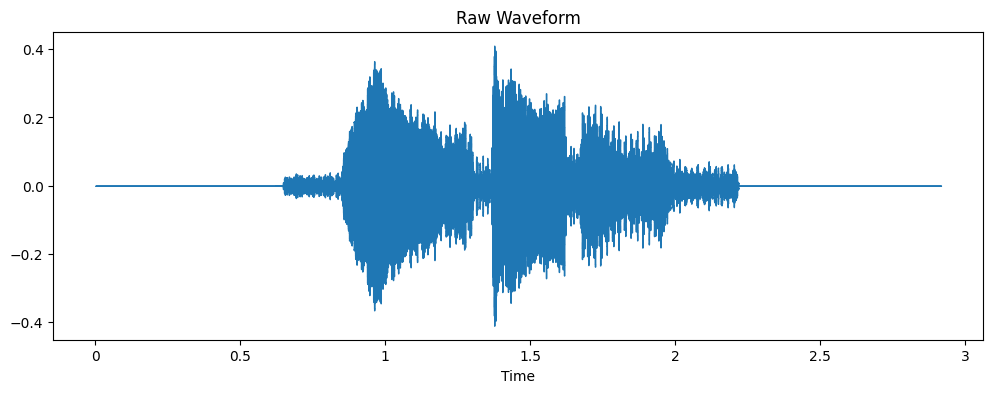

In [ ]:
# Audio Analysis Test

# Load a sample
y, sr, word, metadata = dataset.get_audio_sample()[0]
audio_sample = AudioSample(y, sr, metadata)

# Audio analysis
audio_analyzer = AudioAnalyzer(audio_sample)
audio_analyzer.raw_waveform_plot()



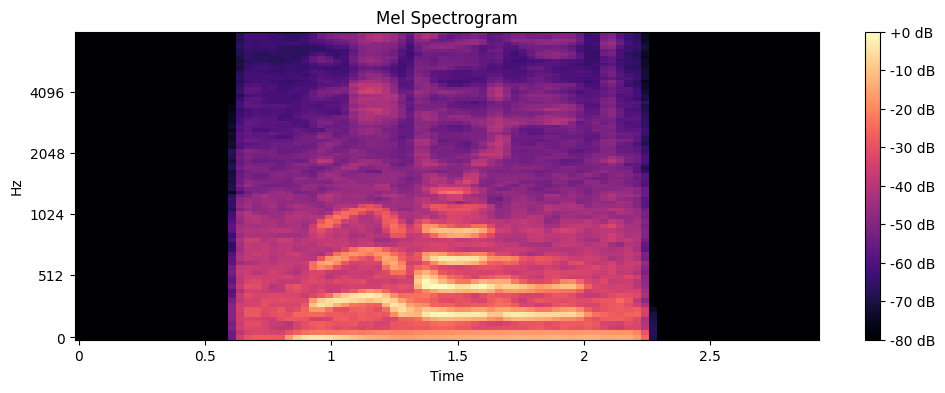

In [ ]:
audio_analyzer.mel_spectrogram_plot()
plt.show()

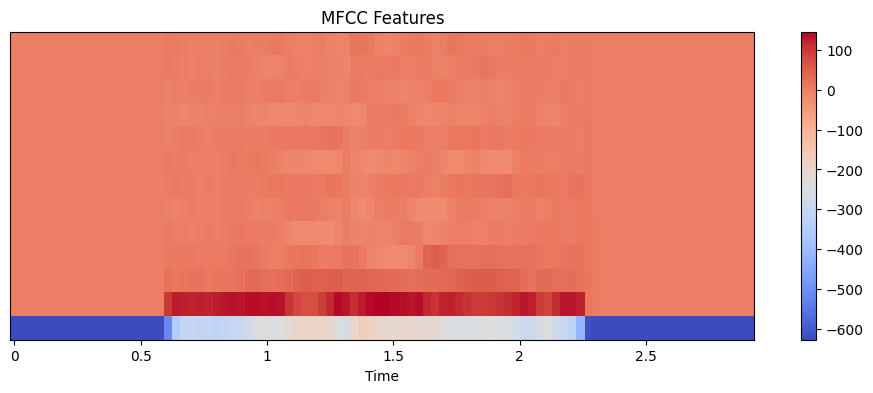

In [ ]:
audio_analyzer.mfcc_plot()

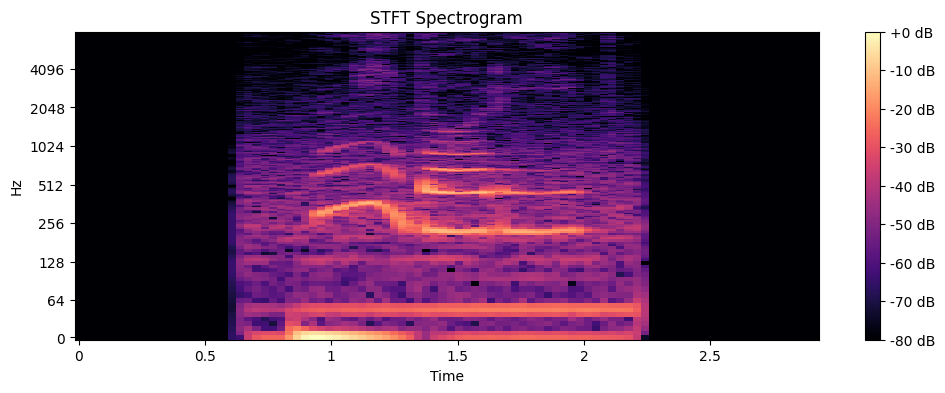

In [ ]:
audio_analyzer.stft_spectrogram_plot()

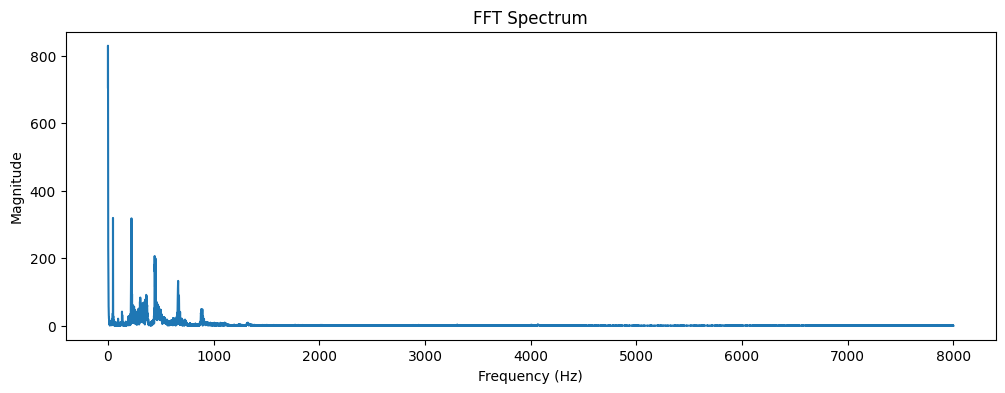

In [ ]:
audio_analyzer.fft_spectrum_plot()

In [ ]:
ipd.Audio(y, rate=sr)

In [ ]:
# Word analysis Test
word_stats = dataset.word_analyzer.word_count()
word_stats

,Persian Word,Voice Count,Folder Count
0,می گوید,14,1
1,آب,50,2
2,آب دوغ,21,1
3,آب شش,38,2
4,آب مروارید,18,1
...,...,...,...
3637,یرسند,18,1
3638,یلدا,20,1
3639,یوزپلنگ,20,1
3640,یکسان,30,1


In [ ]:
top_words = dataset.word_analyzer.most_common_words(10)
top_words

,Persian Word,Voice Count,Folder Count
1300,رسید,82,4
1550,سلام,80,3
1120,دسر,76,3
1595,سگ,70,3
1899,عجله,70,3
3082,هیچ,70,3
3053,هدف,70,3
2072,قاب,68,3
2112,قلب,68,3
5,آب نما,68,3


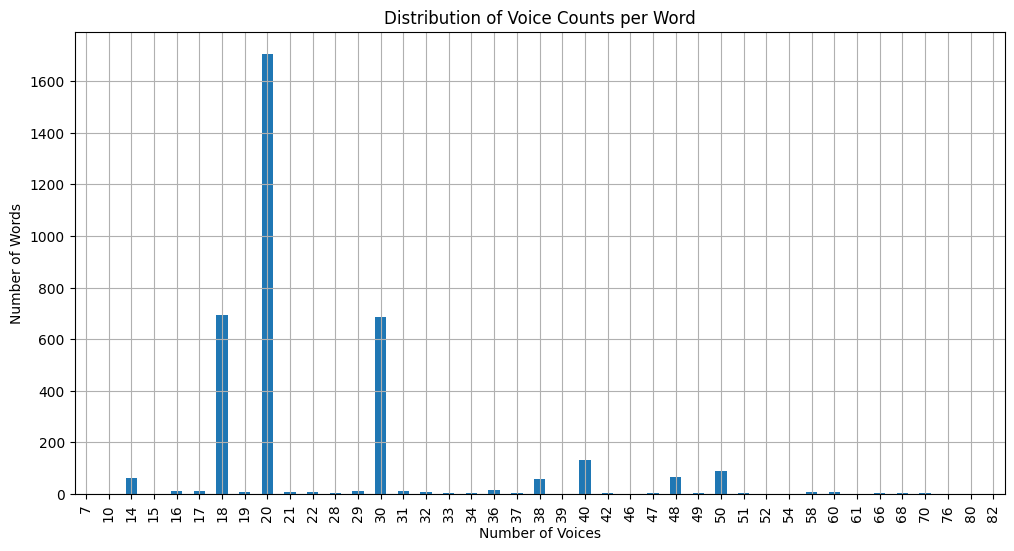

In [ ]:
dataset.word_analyzer.plot_voice_distribution()

In [ ]:
# Dataset statistics Test
duration_stats = dataset.stats.analyze_durations()
duration_stats

Analyzing durations: 100%|██████████| 4018/4018 [02:54<00:00, 23.07it/s]


{'avg': 3.1220696091084514,
 'max': 8.9836875,
 'min': 1.3166875,
 'above_avg': 38685,
 'below_avg': 49837,
 'total_files': 88522}

Sampling durations: 100%|██████████| 500/500 [00:01<00:00, 265.15it/s]


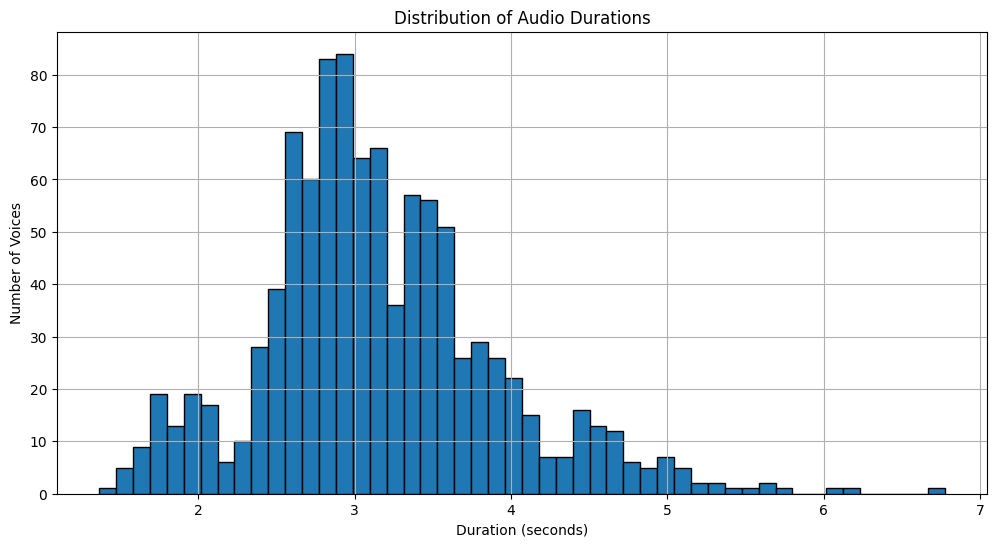

In [ ]:
dataset.stats.plot_duration_distribution()

Exploratory Data Analysis

📝 **RESULT:**



> Dataset Information: It's not good, the distribution and mis-place of voices in a folder is too much (the word is "سیب" but the voice is "پرتقال"). some of voices are not good. Dataset has good denoising and it really don't need any preprocessing but we can just use **Trim Silence, padding or trimmming, loudness normalization, normalization** preprocessing, also don't need any


```
Dataset Problem:
  feature extraction just mfcc or mel-spectrograms.
  The duration distribution is acceptable and don't need anything.
  The voice count of some words are not good and should be fixed.
  Some voices has more than avg duration which is 3.122s(like 8s).
  Some folders or voices are tagged wrongly and should be fixed.
  Lack of having not much dataset for each word and using data augmentation techniques (Maybe creating artificial voices🙂 - need to be researched).

Requirements:
  Researching about what techniques are good for preprocessing and feature extraction.
  What techniques should we do for solving our problems.
```





# *3. Preprocessing*

Writing Preprocessing Functions - (Assignee: Mohammad)\
Sprint Goal: [Writing important functions for speech preprocessing]\
Deadline: 02/May

In [ ]:
#TODO: Writing each function in a cell with example running

# *4. Feature Extraction*

Writing Feature Extraction Functions - (Assignee: Shakiba)\
Sprint Goal: [Writing function for extracting features from voices for different model training]\
Deadline: 02/May

In [ ]:
#TODO: Writing each feature extraction function in a cell with example (maybe some function need some preprocessing, if it is please comment on that)

# *5. Model Training*

# *6. Evaluation and Prediction*

# *7. Deployment*

# *8. Model no.1*

Testing Trained Model - (Assignee: Sepehr)\
Sprint Goal: [Importing a trained persian model to test dataset how good is it]\
Deadline: 02/May

In [ ]:
# for evaluation in huggingface

class ASREvaluator:
    def __init__(self, dataset, model_name="m3hrdadfi/wav2vec2-large-xlsr-persian"):
        self.dataset = dataset
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model = Wav2Vec2ForCTC.from_pretrained(model_name)
        self.wer_metric = load("wer")
        self.cer_metric = load("cer")

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=16000)

    def _preprocess_audio(self, waveform, sample_rate):
        """Resample and prepare audio for model"""
        self.resampler.orig_freq = sample_rate
        waveform = self.resampler(waveform)
        return waveform.squeeze()

    def _transcribe(self, waveform):
        """Run inference on single audio sample"""
        inputs = self.processor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        ).to(self.device)

        with torch.no_grad():
            logits = self.model(**inputs).logits

        pred_ids = torch.argmax(logits, dim=-1)
        return self.processor.batch_decode(pred_ids)[0]

    def evaluate_split(self, split="test", max_samples=None):
        """
        Evaluate model on a dataset split
        Args:
            split: 'train', 'test', or 'valid'
            max_samples: maximum samples to evaluate (None for all)
        Returns:
            dict: {'wer': float, 'cer': float, 'samples': list}
        """
        if split not in ["train", "test", "valid"]:
            raise ValueError("Split must be train/test/valid")

        indices = getattr(self.dataset, f"{split}_indices")
        if max_samples:
            indices = indices[:max_samples]

        results = {
            'actual': [],
            'predicted': [],
            'wer': [],
            'cer': []
        }

        for idx in tqdm(indices, desc=f"Evaluating {split} set"):
            try:
                audio_data = self.dataset.get_audio_sample(index=idx)
                waveform, sample_rate, actual_word = audio_data[0][:-1]

                waveform = self._preprocess_audio(waveform, sample_rate)
                predicted_text = self._transcribe(waveform)

                wer = self.wer_metric.compute(
                    predictions=[predicted_text],
                    references=[actual_word]
                )
                cer = self.cer_metric.compute(
                    predictions=[predicted_text],
                    references=[actual_word]
                )

                results['actual'].append(actual_word)
                results['predicted'].append(predicted_text)
                results['wer'].append(wer)
                results['cer'].append(cer)

            except Exception as e:
                print(f"Error processing sample {idx}: {str(e)}")
                continue

        avg_wer = sum(results['wer']) / len(results['wer'])
        avg_cer = sum(results['cer']) / len(results['cer'])

        return {
            'wer': avg_wer,
            'cer': avg_cer,
            'samples': list(zip(results['actual'], results['predicted']))
        }

    def evaluate_all(self, max_samples_per_split=100):
        """Evaluate on all splits"""
        return {
            'train': self.evaluate_split('train', max_samples_per_split),
            'valid': self.evaluate_split('valid', max_samples_per_split),
            'test': self.evaluate_split('test', max_samples_per_split)
        }

In [ ]:
model_name = "m3hrdadfi/wav2vec2-large-xlsr-persian"
processor = Wav2Vec2Processor.from_pretrained(model_name)
model = Wav2Vec2ForCTC.from_pretrained(model_name)

audio_file = dataset.get_audio_sample()

waveform, sample_rate, word = audio_file[0][:-1]
resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
waveform = resampler(waveform)

inputs = processor(waveform.squeeze(), sampling_rate=16000, return_tensors="pt", padding=True)

with torch.no_grad():
    logits = model(**inputs).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)[0]

print("Actual word:", word)
print("Transcription:", transcription)
ipd.Audio(waveform, rate=sample_rate)


/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Actual word: بزکوهی
Transcription: بوز کوهی


In [ ]:
evaluator = ASREvaluator(dataset)

test_results = evaluator.evaluate_split('test', max_samples=50)
print(f"WER: {test_results['wer']:.2%}")
print(f"CER: {test_results['cer']:.2%}")

for i, (actual, predicted) in enumerate(test_results['samples'][:5]):
    print(f"\nSample {i+1}:")
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")

/usr/local/lib/python3.11/dist-packages/transformers/configuration_utils.py:311: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Evaluating test set: 100%|██████████| 50/50 [02:32<00:00,  3.05s/it]

WER: 44.00%
CER: 12.21%

Sample 1:
Actual: رژه
Predicted: رژه

Sample 2:
Actual: می گرفت
Predicted: می گرفتیم

Sample 3:
Actual: خجالت
Predicted: خجالت

Sample 4:
Actual: می ماندید
Predicted: میماندید

Sample 5:
Actual: هدایت
Predicted: هدایت


In [ ]:
model = whisper.load_model("base")
result = model.transcribe("your_audio.wav", language="fa")
transcription = result["text"]

print("Transcription:", transcription)
